# Day 30: LangGraph Intro

`create_agent` is a black box. It works — but you can't see inside.

LangGraph opens the box. Your workflow is an explicit graph: **nodes** do work, **edges** connect them.

## Install

In [ ]:
%pip install langgraph langchain-google-genai --quiet

## Setup

In [23]:
import os
from dotenv import load_dotenv
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_google_genai import ChatGoogleGenerativeAI

load_dotenv(dotenv_path='../.env')
os.environ["GOOGLE_API_KEY"] = os.environ["GEMINI_API_KEY2"]

model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


## Define State

In [24]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

print("✅ State defined — holds a list of messages")

✅ State defined — holds a list of messages


## Define a Node

In [25]:
def call_model(state: State):
    """Node: send messages to Gemini, return the response."""
    response = model.invoke(state["messages"])
    return {"messages": [response]}

print("✅ Node defined — call_model")

✅ Node defined — call_model


## Build the Graph

In [26]:
builder = StateGraph(State)

builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")
builder.add_edge("call_model", END)

graph = builder.compile()
print("✅ Graph compiled")

✅ Graph compiled


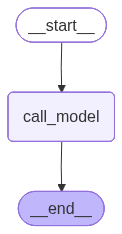

In [27]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

## Run It

In [28]:
result = graph.invoke({"messages": [{"role": "user", "content": "What is LangGraph in one sentence?"}]})
print(result["messages"][-1].content)

LangGraph is a library that uses a graph structure to orchestrate stateful, multi-actor applications with LLMs, enabling complex conditional logic and cycles for building robust agents and workflows.


## Multi-Node Graph

In [29]:
# Node 1: research the topic
def research(state: State):
    prompt = state["messages"] + [{"role": "user", "content": "Give me 3 key facts about this topic."}]
    response = model.invoke(prompt)
    return {"messages": [response]}

# Node 2: summarize into one line
def summarize(state: State):
    prompt = state["messages"] + [{"role": "user", "content": "Now summarize everything in one sentence."}]
    response = model.invoke(prompt)
    return {"messages": [response]}

In [30]:
builder2 = StateGraph(State)

builder2.add_node("research", research)
builder2.add_node("summarize", summarize)
builder2.add_edge(START, "research")
builder2.add_edge("research", "summarize")
builder2.add_edge("summarize", END)

graph2 = builder2.compile()
print("✅ 2-node graph compiled: research → summarize")

✅ 2-node graph compiled: research → summarize


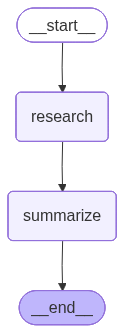

In [31]:
display(Image(graph2.get_graph().draw_mermaid_png()))

In [32]:
result = graph2.invoke({"messages": [{"role": "user", "content": "Tell me about black holes"}]})
print(result["messages"][-1].content)

Black holes are regions of spacetime with such immense gravity, defined by an event horizon, that nothing can escape, forming mainly from massive stars and detected by their influence on surrounding matter.


## Key Takeaways

1. A LangGraph graph is **State + Nodes + Edges** — explicit, inspectable, controllable
2. `add_messages` in state automatically **appends** messages instead of replacing them
3. Multi-node graphs let you **chain LLM calls** — `create_agent` was just one of these under the hood